In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

In [2]:
# Load Dataset

file_path = r"C:\Users\Hp\Downloads\online+retail+ii\online_retail_II.xlsx"

# Load both sheets
sheet1 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
sheet2 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

# Combine datasets
retail_df = pd.concat([sheet1, sheet2], ignore_index=True)

print(retail_df.head())
print(retail_df.shape)


  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041          RECORD FRAME 7" SINGLE SIZE        48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
(1067371, 8)


In [3]:
retail_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
# Data Cleaning

# Remove missing values
retail_df.dropna(inplace=True)

# Remove cancelled orders
retail_df = retail_df[~retail_df['Invoice'].astype(str).str.contains('C')]

# Remove negative quantity
retail_df = retail_df[retail_df['Quantity'] > 0]

# Convert InvoiceDate into datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Create Revenue column
retail_df['Revenue'] = retail_df['Quantity'] * retail_df['Price']

print(retail_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  object        
 8   Revenue      805620 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB
None


In [5]:
#Create Daily Sales Time Series

# Group by date
sales_df = retail_df.groupby(retail_df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()

# Rename columns
sales_df.columns = ['Date', 'Sales']

# Convert Date column
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Set index
sales_df.set_index('Date', inplace=True)

print(sales_df.head())

               Sales
Date                
2009-12-01  44048.69
2009-12-02  52941.99
2009-12-03  67479.08
2009-12-04  34064.41
2009-12-05   9803.05


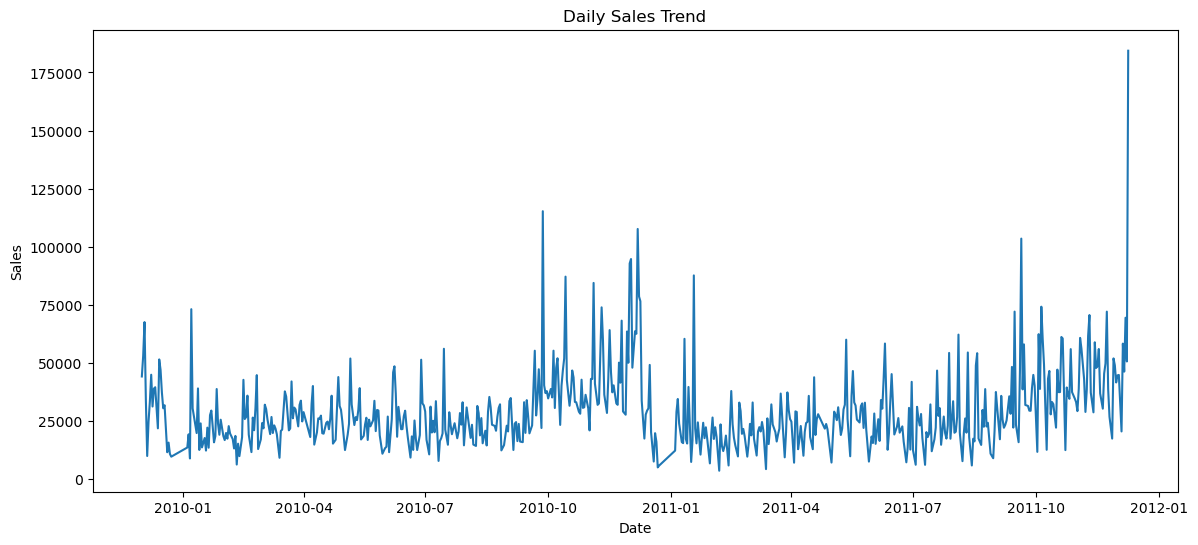

In [6]:
# Visualize Sales Trend

plt.figure(figsize=(14,6))
plt.plot(sales_df)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [7]:
# Train-Test Split

train_size = int(len(sales_df) * 0.80)

train = sales_df.iloc[:train_size]
test = sales_df.iloc[train_size:]

print(train.shape)
print(test.shape)

(483, 1)
(121, 1)


In [8]:
# ARIMA MODEL

# Build ARIMA Model
# ARIMA(p,d,q)
model_arima = ARIMA(train['Sales'], order=(5,1,2))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  483
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5235.041
Date:                Tue, 26 May 2026   AIC                          10486.081
Time:                        10:28:17   BIC                          10519.505
Sample:                             0   HQIC                         10499.217
                                - 483                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6163      0.227     -2.716      0.007      -1.061      -0.172
ar.L2         -0.7135      0.107     -6.651      0.000      -0.924      -0.503
ar.L3         -0.5159      0.096     -5.352      0.0

In [9]:
# ARIMA Forecast

arima_forecast = model_arima_fit.forecast(steps=len(test))

# Evaluation
mae_arima = mean_absolute_error(test['Sales'], arima_forecast)
rmse_arima = sqrt(mean_squared_error(test['Sales'], arima_forecast))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 16203.320070235728
ARIMA RMSE: 24133.378685725325


C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


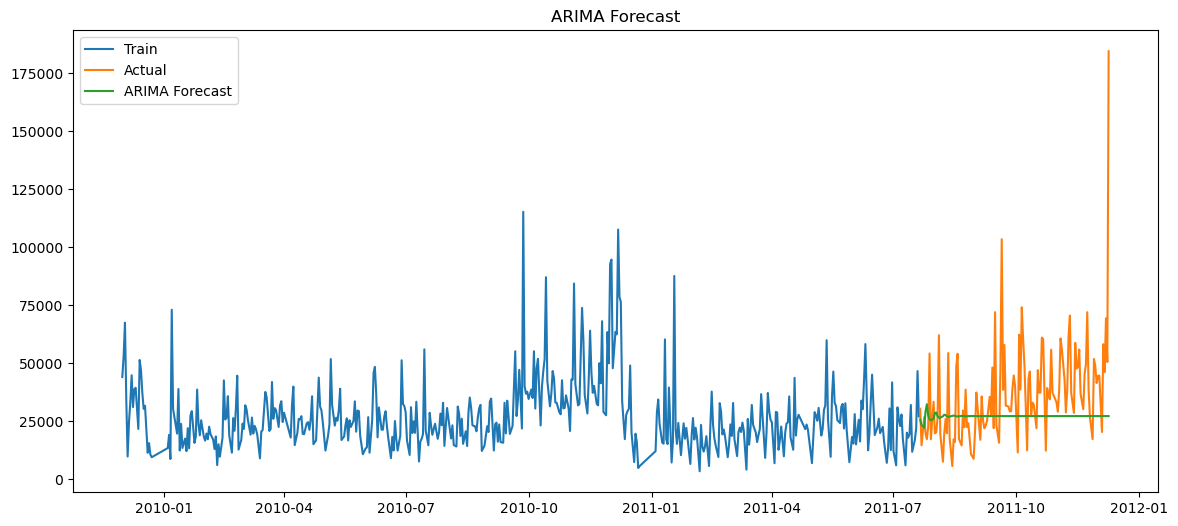

In [10]:
# ARIMA Visualization

plt.figure(figsize=(14,6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

In [11]:
# SARIMA MODEL

# Build SARIMA Model

sarima_model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  483
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -5158.229
Date:                            Tue, 26 May 2026   AIC                          10326.457
Time:                                    10:32:35   BIC                          10347.221
Sample:                                         0   HQIC                         10334.626
                                            - 483                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2081      0.087      2.394      0.017       0.038       0.379
ma.L1         -0.8392      0.046   

In [12]:
# SARIMA Forecast

sarima_forecast = sarima_fit.forecast(steps=len(test))

# Evaluation
mae_sarima = mean_absolute_error(test['Sales'], sarima_forecast)
rmse_sarima = sqrt(mean_squared_error(test['Sales'], sarima_forecast))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 17795.524695823206
SARIMA RMSE: 25760.888854437737


C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


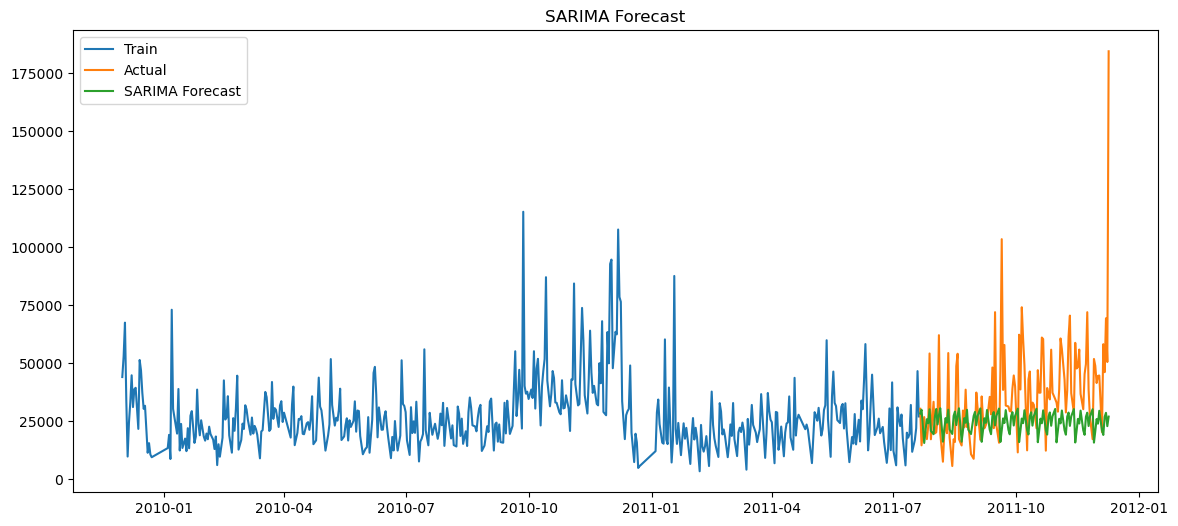

In [13]:
# SARIMA Visualization

plt.figure(figsize=(14,6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA Forecast')
plt.show()

In [14]:
# PROPHET MODEL

# Prepare Data for Prophet

prophet_df = sales_df.reset_index()
prophet_df.columns = ['ds', 'y']

# Train-test split
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [15]:
# Train Prophet Model

prophet_model = Prophet()
prophet_model.fit(train_prophet)

10:34:32 - cmdstanpy - INFO - Chain [1] start processing
10:34:33 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
# Prophet Forecast

future = prophet_model.make_future_dataframe(periods=len(test_prophet))
forecast = prophet_model.predict(future)

# Get predictions
prophet_forecast = forecast[['ds', 'yhat']].tail(len(test_prophet))

In [17]:
# Prophet Forecast

future = prophet_model.make_future_dataframe(periods=len(test_prophet))
forecast = prophet_model.predict(future)

# Get predictions
prophet_forecast = forecast[['ds', 'yhat']].tail(len(test_prophet))

In [26]:
# Prophet Evaluation
mae_prophet = mean_absolute_error(test_prophet['y'], prophet_forecast['yhat'])
rmse_prophet = sqrt(mean_squared_error(test_prophet['y'], prophet_forecast['yhat']))

print("PROPHET MAE:", mae_prophet)
print("PROPHET RMSE:", rmse_prophet)

PROPHET MAE: 24056.041987261175
PROPHET RMSE: 32298.889217666027


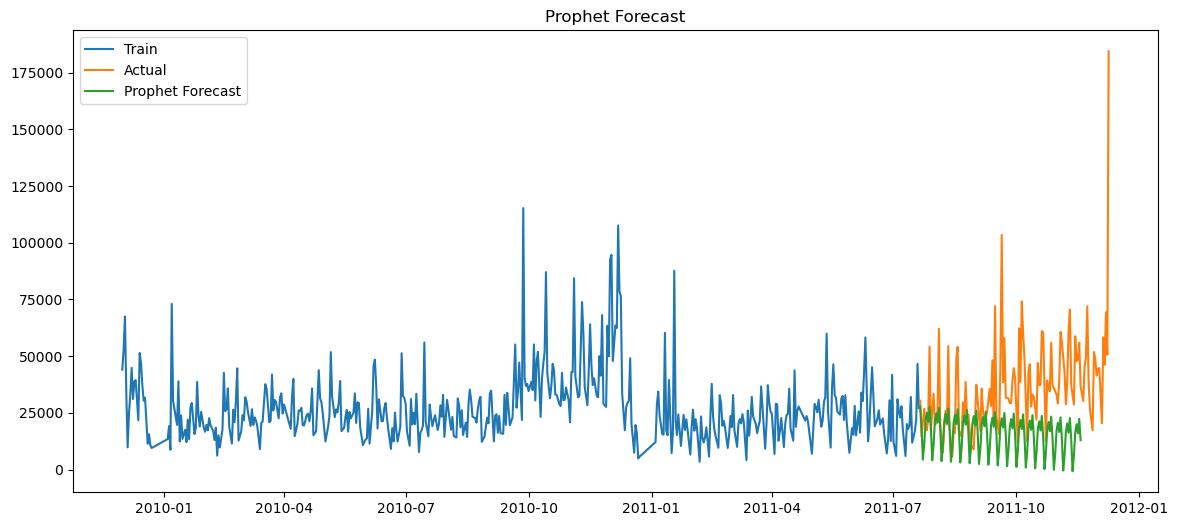

In [18]:
# Prophet Visualization

plt.figure(figsize=(14,6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual')
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast')
plt.legend()
plt.title('Prophet Forecast')
plt.show()

In [27]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'PROPHET'],
    'MAE': [mae_arima, mae_sarima, mae_prophet],
    'RMSE': [rmse_arima, rmse_sarima, rmse_prophet]
})

print(comparison)

     Model           MAE          RMSE
0    ARIMA  16203.320070  24133.378686
1   SARIMA  17795.524696  25760.888854
2  PROPHET  24056.041987  32298.889218


In [28]:
best_model = comparison.sort_values('RMSE').iloc[0]

print('Best Model:')
print(best_model)

Best Model:
Model           ARIMA
MAE       16203.32007
RMSE     24133.378686
Name: 0, dtype: object
